# Evaluación integral del Contextizer Híbrido

In [1]:
"""
Evaluación integral del Contextizer Híbrido (modo completo)
-----------------------------------------------------------
Analiza las métricas de contextualización de documentos
para evaluar la calidad, coherencia y diversidad semántica
del modelo en la configuración:
    use_hybrid=True, use_keybert=True, enable_mmr=True
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================================
# 1 Cargar los datos
# ======================================================
# Reemplaza con la ruta de tu Excel o CSV
df = pd.read_excel("data/contextizer_metrics.xlsx")  # o pd.read_csv("contextizer_metrics.csv")

# Asegura nombres consistentes
df.columns = [c.strip() for c in df.columns]


In [2]:
# ======================================================
# 2 Limpiar y normalizar métricas
# ======================================================
metrics = [
    "Coverage", "Outlier Rate", "Topic Size (Median)",
    "Keyword Diversity (basic)", "Entropy", "Redundancy",
    "Keyword Diversity (ext)", "Semantic Variance", "Semantic Coherence"
]

# Convierte todo a float
for m in metrics:
    df[m] = pd.to_numeric(df[m], errors="coerce").fillna(0.0)

In [3]:
# ======================================================
# 3 Calcular el Contextization Score
# ======================================================
def compute_contextization_score(row):
    coverage = row["Coverage"]
    entropy = row["Entropy"]
    redundancy = row["Redundancy"]
    diversity_ext = row["Keyword Diversity (ext)"]
    coherence = row["Semantic Coherence"]
    variance = row["Semantic Variance"]
    
    # normalizaciones y penalizaciones
    score = (
        0.2 * coverage +
        0.15 * entropy +
        0.15 * (1 - redundancy) +
        0.25 * diversity_ext +
        0.15 * (1 - abs(coherence - 0.45)) +  # coherencia óptima ≈ 0.45
        0.1  * (1 - abs(variance - 0.4))      # varianza óptima ≈ 0.4
    )
    return round(score, 3)

df["Contextization_Score"] = df.apply(compute_contextization_score, axis=1)

In [4]:
# ======================================================
# 4 Estadísticas generales
# ======================================================
print("\n📊 Estadísticas globales del modelo:\n")
print(df[metrics + ["Contextization_Score"]].describe().T[["mean", "std", "min", "max"]])



📊 Estadísticas globales del modelo:

                               mean        std       min      max
Coverage                   1.000000   0.000000  1.000000   1.0000
Outlier Rate               0.000000   0.000000  0.000000   0.0000
Topic Size (Median)        6.508772  10.116505  1.000000  53.0000
Keyword Diversity (basic)  0.883363   0.245234  0.000000   1.0000
Entropy                    0.188499   0.389280  0.000000   1.0000
Redundancy                 0.000000   0.000000  0.000000   0.0000
Keyword Diversity (ext)    0.892485   0.243815  0.000000   1.0000
Semantic Variance          0.062749   0.140691  0.000000   0.5632
Semantic Coherence         0.357230   0.180963  0.239171   1.0000
Contextization_Score       0.791316   0.086477  0.477000   0.9270


In [5]:
# ======================================================
# 5 Análisis de desempeño por fuente (Wikipedia, Yahoo, etc.)
# ======================================================
print("\n🌐 Promedios por fuente:\n")
print(df.groupby("Fuente")[["Coverage", "Entropy", "Redundancy", 
                            "Keyword Diversity (ext)", "Semantic Coherence", "Contextization_Score"]].mean().round(3))



🌐 Promedios por fuente:

               Coverage  Entropy  Redundancy  Keyword Diversity (ext)  \
Fuente                                                                  
CV                  1.0    0.000         0.0                    1.000   
Reuters             1.0    0.000         0.0                    0.000   
Wikipedia           1.0    0.224         0.0                    0.935   
Yahoo Finance       1.0    0.000         0.0                    0.333   
Yelp                1.0    0.000         0.0                    1.000   

               Semantic Coherence  Contextization_Score  
Fuente                                                   
CV                          0.240                 0.778  
Reuters                     1.000                 0.477  
Wikipedia                   0.326                 0.812  
Yahoo Finance               0.765                 0.580  
Yelp                        0.294                 0.787  


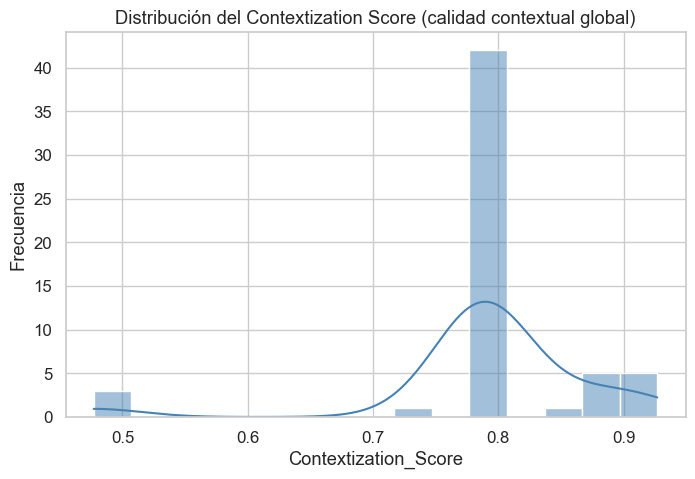

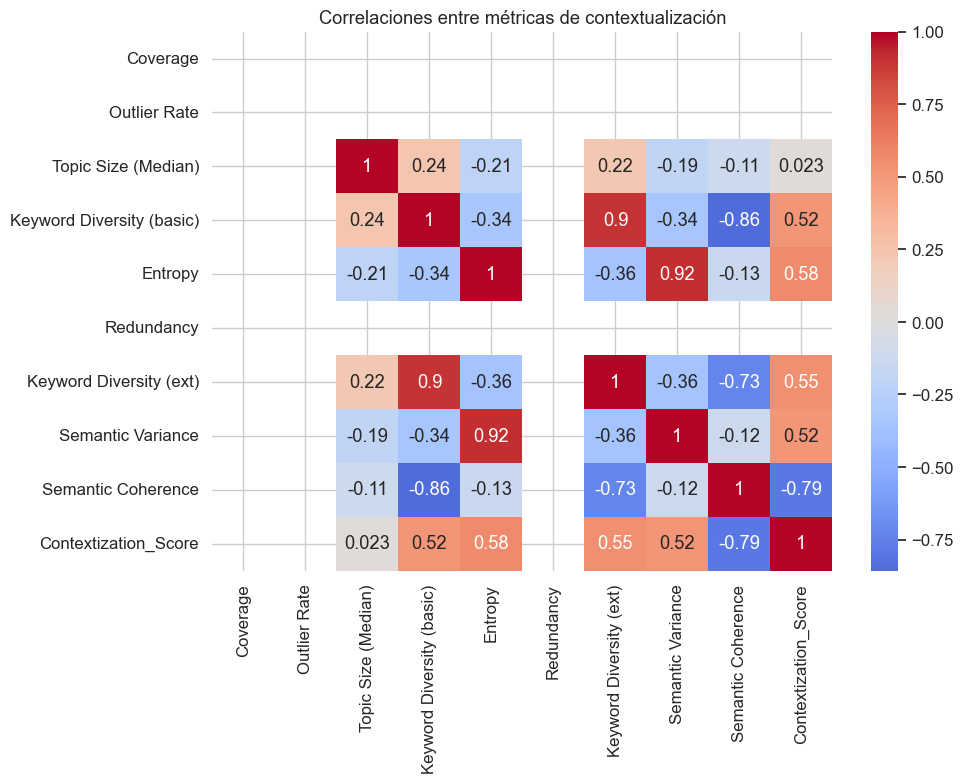

/var/folders/sm/vkxvnt3d3230grm_m_d823c80000gn/T/ipykernel_2850/2957829020.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Fuente", y="Contextization_Score", palette="viridis")


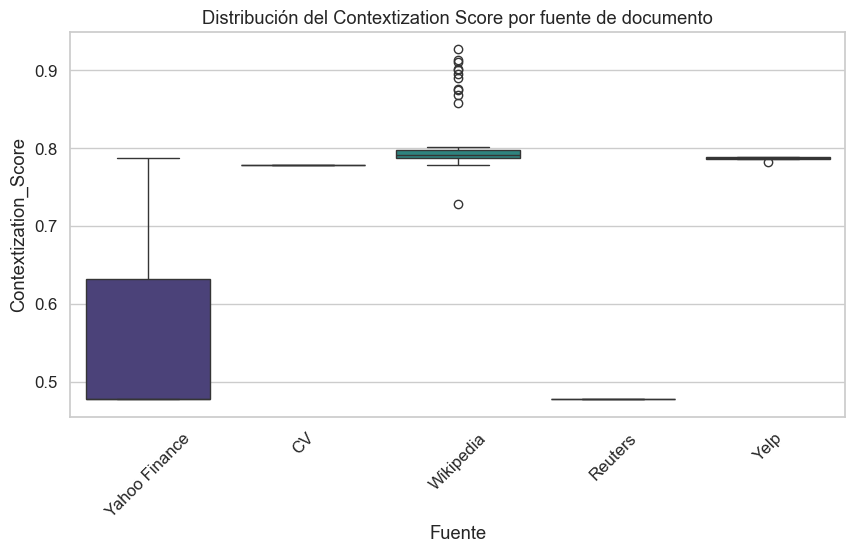

In [6]:
# ======================================================
# 6 Visualizaciones clave
# ======================================================
sns.set(style="whitegrid", font_scale=1.1)

# Distribución del Contextization Score
plt.figure(figsize=(8,5))
sns.histplot(df["Contextization_Score"], bins=15, color="steelblue", kde=True)
plt.title("Distribución del Contextization Score (calidad contextual global)")
plt.xlabel("Contextization_Score")
plt.ylabel("Frecuencia")
plt.show()

# Correlaciones entre métricas
plt.figure(figsize=(10,7))
sns.heatmap(df[metrics + ["Contextization_Score"]].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlaciones entre métricas de contextualización")
plt.show()

# Comparativa por fuente
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Fuente", y="Contextization_Score", palette="viridis")
plt.title("Distribución del Contextization Score por fuente de documento")
plt.xticks(rotation=45)
plt.show()

In [7]:
# ======================================================
# 7 Diagnóstico cualitativo automático
# ======================================================
def diagnose_model(df):
    mean_cov = df["Coverage"].mean()
    mean_ent = df["Entropy"].mean()
    mean_red = df["Redundancy"].mean()
    mean_div = df["Keyword Diversity (ext)"].mean()
    mean_coh = df["Semantic Coherence"].mean()
    mean_var = df["Semantic Variance"].mean()
    score = df["Contextization_Score"].mean()

    print("\n🧭 Diagnóstico automático del modelo híbrido:\n")

    if score > 0.8:
        print(" Excelente contextualización: alta diversidad y coherencia equilibrada.")
    elif score > 0.6:
        print("🟢 Buena calidad contextual: el modelo agrupa y diversifica correctamente.")
    elif score > 0.4:
        print("🟡 Aceptable: contextualiza pero con redundancias o temas amplios.")
    else:
        print("🔴 Bajo desempeño: revisar eps/min_samples o embeddings.")

    print(f"""
📈 Promedios:
• Coverage: {mean_cov:.2f}
• Entropy: {mean_ent:.2f}
• Redundancy: {mean_red:.2f}
• Diversity_ext: {mean_div:.2f}
• Coherence: {mean_coh:.2f}
• Variance: {mean_var:.2f}
• Contextization Score promedio: {score:.3f}
""")

diagnose_model(df)


🧭 Diagnóstico automático del modelo híbrido:

🟢 Buena calidad contextual: el modelo agrupa y diversifica correctamente.

📈 Promedios:
• Coverage: 1.00
• Entropy: 0.19
• Redundancy: 0.00
• Diversity_ext: 0.89
• Coherence: 0.36
• Variance: 0.06
• Contextization Score promedio: 0.791



In [8]:
# -*- coding: utf-8 -*-
"""
Bloque para generar diagnóstico interpretativo del Contextizer Híbrido
Autor: Martín Jurado
Integrable en: t2g_evaluation/scripts/analyze_contextizer.py

Analiza métricas globales del Contextizer Híbrido, las clasifica según
umbrales de referencia oficiales (Coverage, Entropy, Variance, etc.)
y genera un informe Markdown autoexplicativo con diagnóstico global
y por categoría (estructura, diversidad y coherencia).
"""

import numpy as np
import pandas as pd

# ======================================================
# FUNCIÓN DE EVALUACIÓN POR MÉTRICA (SEMÁFORO PARAMÉTRICO)
# ======================================================
def evaluate_metric(metric, value):
    """Evalúa una métrica del Contextizer según los rangos oficiales.
    Devuelve (emoji, nivel, interpretación)."""
    
    if metric == "Coverage":
        if value >= 0.9: return "🟢", "Ideal", "Excelente cobertura (todos los fragmentos contextualizados)"
        elif value >= 0.7: return "🟡", "Aceptable", "Cobertura parcial, posible dispersión temática"
        else: return "🔴", "Problema", "Cobertura insuficiente"
    
    elif metric == "Outlier Rate":
        if value <= 0.1: return "🟢", "Ideal", "Sin ruido"
        elif value <= 0.3: return "🟡", "Aceptable", "Algunos fragmentos ruidosos"
        else: return "🔴", "Problema", "Ruido excesivo o clusters mal formados"
    
    elif metric == "Entropy":
        if value >= 0.8: return "🟢", "Ideal", "Tópicos balanceados en tamaño"
        elif value >= 0.5: return "🟡", "Aceptable", "Algunos tópicos dominantes"
        else: return "🔴", "Problema", "Entropía baja (un tópico domina)"
    
    elif metric == "Redundancy":
        if value <= 0.2: return "🟢", "Ideal", "Tópicos bien diferenciados"
        elif value <= 0.4: return "🟡", "Aceptable", "Solapamiento leve"
        else: return "🔴", "Problema", "Tópicos redundantes o duplicados"
    
    elif metric in ["Keyword Diversity (basic)", "Keyword Diversity (ext)"]:
        if value >= 0.8: return "🟢", "Ideal", "Alta diversidad (léxica o semántica)"
        elif value >= 0.5: return "🟡", "Aceptable", "Diversidad moderada"
        else: return "🔴", "Problema", "Baja diversidad (palabras repetidas o sinónimos)"
    
    elif metric == "Semantic Variance":
        if 0.3 <= value <= 0.5: return "🟢", "Óptima", "Variedad semántica equilibrada"
        elif 0.2 <= value < 0.3 or 0.5 < value <= 0.6:
            return "🟡", "Límite", "Podría mejorar la heterogeneidad semántica"
        else:
            return "🔴", "Fuera de rango", "Tópicos demasiado homogéneos o dispersos"
    
    elif metric == "Semantic Coherence":
        if 0.3 <= value <= 0.6: return "🟢", "Óptima", "Coherencia interna adecuada"
        elif 0.2 <= value < 0.3 or 0.6 < value <= 0.8:
            return "🟡", "Límite", "Coherencia excesiva o insuficiente"
        else:
            return "🔴", "Problema", "Incoherente o redundante"
    
    else:
        return "⚪", "N/A", "Métrica no clasificada"


# ======================================================
# FUNCIÓN PRINCIPAL DE REPORTE
# ======================================================
def generate_diagnostic_report(df, output_path="contextizer_diagnostic_report.md"):
    """Genera el informe de diagnóstico a partir de un DataFrame con métricas del Contextizer."""
    
    # --- Métricas promedio ---
    mean_cov = df["Coverage"].mean()
    mean_out = df["Outlier Rate"].mean()
    mean_topic = df["Topic Size (Median)"].mean()
    mean_div = df["Keyword Diversity (basic)"].mean()
    mean_ent = df["Entropy"].mean()
    mean_red = df["Redundancy"].mean()
    mean_div_ext = df["Keyword Diversity (ext)"].mean()
    mean_var = df["Semantic Variance"].mean()
    mean_coh = df["Semantic Coherence"].mean()
    mean_score = df["Contextization_Score"].mean()

    # --- Diagnóstico global ---
    if mean_score > 0.8:
        quality_tag = "🟢 Excelente calidad contextual: robusta y estable."
    elif mean_score > 0.6:
        quality_tag = "🟢 Buena calidad contextual: el modelo agrupa y diversifica correctamente."
    elif mean_score > 0.4:
        quality_tag = "🟡 Aceptable: contextualiza pero con redundancias o baja diversidad."
    else:
        quality_tag = "🔴 Bajo desempeño: revisar eps, embeddings o segmentación."

    # ======================================================
    # 1️⃣ SECCIÓN: DIAGNÓSTICO GENERAL DETALLADO
    # ======================================================
    metrics = [
        "Coverage", "Outlier Rate", "Topic Size (Median)",
        "Keyword Diversity (basic)", "Entropy", "Redundancy",
        "Keyword Diversity (ext)", "Semantic Variance", "Semantic Coherence"
    ]

    values = [
        mean_cov, mean_out, mean_topic, mean_div,
        mean_ent, mean_red, mean_div_ext, mean_var, mean_coh
    ]

    rows = []
    for m, v in zip(metrics, values):
        emoji, status, interp = evaluate_metric(m, v)
        rows.append(f"| **{m} = {v:.2f}** | {emoji} {status}: {interp} |")

    section1 = (
        "# 🧭 Diagnóstico General del Modelo\n\n"
        "| Métrica | Evaluación |\n|----------|-------------|\n" + "\n".join(rows) +
        f"\n\n📊 **Diagnóstico final:**\n> “{quality_tag} "
        f"La entropía {'baja' if mean_ent < 0.4 else 'adecuada'} indica "
        f"{'poca diversidad temática' if mean_ent < 0.4 else 'buen equilibrio de tópicos'}.”\n"
    )

    # ======================================================
    # 2️⃣ SECCIÓN: DESEMPEÑO POR FUENTE
    # ======================================================
    fuentes = df.groupby("Fuente")[["Contextization_Score"]].mean().round(3)
    fuentes_table = fuentes.to_markdown()

    section2 = f"""
# 🔍 2. Desempeño por Fuente de Documento

{fuentes_table}

📦 **Interpretación general:**
- Fuentes con mayor `Contextization_Score` indican textos más ricos y narrativos (mayor diversidad).
- Valores bajos reflejan documentos técnicos o con poco contexto semántico (como Reuters o Yahoo Finance).
"""

    # ======================================================
    # 3️⃣ SECCIÓN: EVALUACIÓN POR CATEGORÍA
    # ======================================================
    categories = {
        "Cobertura y estructura": [mean_cov, 1 - mean_out],
        "Diversidad y separación": [mean_div_ext, mean_ent, 1 - mean_red],
        "Calidad semántica interna": [mean_var, mean_coh],
    }

    cat_table = []
    for cat, vals in categories.items():
        score = np.mean(vals)
        emoji, status, _ = evaluate_metric("Entropy", score)  # usa Entropy como referencia visual
        cat_table.append(f"| **{cat}** | {score:.2f} | {emoji} {status} |")

    section3 = (
        "# 🧩 3. Evaluación por Categoría\n\n"
        "| Categoría | Score promedio | Diagnóstico |\n|------------|----------------:|--------------|\n"
        + "\n".join(cat_table)
    )

    # ======================================================
    # 4️⃣ SECCIÓN: RECOMENDACIONES AUTOMÁTICAS
    # ======================================================
    recs = []
    if mean_ent < 0.4:
        recs.append("Incrementar `hybrid_eps` (0.2→0.3) para permitir más clusters y aumentar diversidad temática.")
    if mean_var < 0.2:
        recs.append("Probar embeddings más ricos (`all-mpnet-base-v2`) para mayor heterogeneidad semántica.")
    if mean_coh > 0.6:
        recs.append("Revisar MMR o reducir cohesión para evitar redundancia excesiva.")
    if mean_score < 0.7:
        recs.append("Revisar segmentación de chunks o modelo de embeddings base.")
    if not recs:
        recs.append("No se requieren ajustes significativos.")

    section4 = "# 🔧 4. Recomendaciones Técnicas\n\n" + "\n".join(f"- {r}" for r in recs)

    # ======================================================
    # GENERAR Y GUARDAR REPORTE
    # ======================================================
    report = f"{section1}\n\n{section2}\n\n{section3}\n\n{section4}"
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(report)

    print(f" Informe generado: {output_path}")
    return report


In [9]:
report = generate_diagnostic_report(df)

 Informe generado: contextizer_diagnostic_report.md
